## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning
## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

path = kagglehub.dataset_download("uciml/adult-census-income")

print(path)

100%|██████████| 450k/450k [00:21<00:00, 21.9kB/s]

Extracting files...
C:\Users\pache\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


In [4]:
df = pd.read_csv(path + "/adult.csv")

In [5]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# El objetivo es predecir si una persona gana más de $50,000 dólares al año utilizando información demográfica y laboral.

In [8]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [9]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [10]:
(df == "?").sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [11]:
df.replace("?", np.nan, inplace=True)

In [12]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
numericas = df.select_dtypes(include=np.number)

numericas.columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

In [15]:
categoricas = df.select_dtypes(include="object")

categoricas.columns

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')

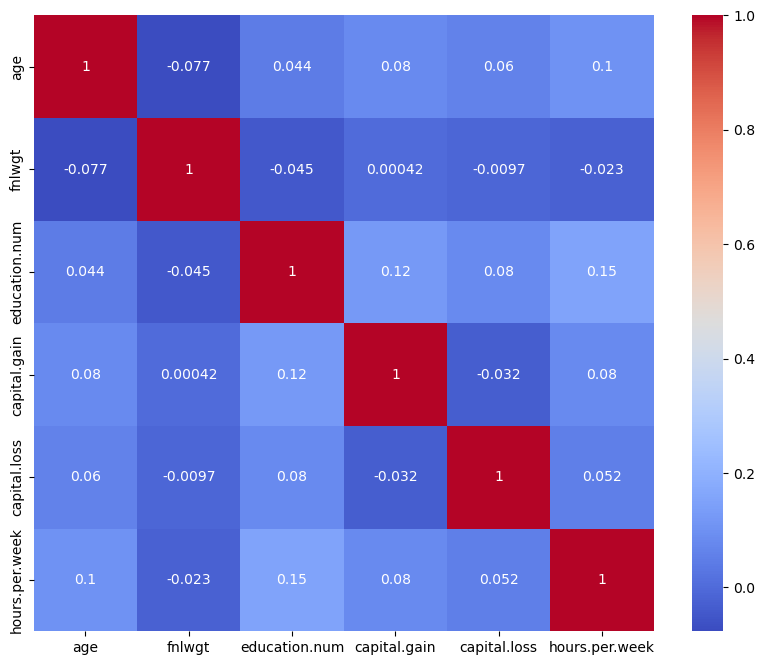

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numericas.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [17]:
X = df.drop("income", axis=1)

y = df["income"]

In [18]:
columnas_antes = X.shape[1]

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
columnas_despues = X.shape[1]

print(columnas_despues - columnas_antes)

82


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [23]:
modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
predicciones = modelo.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, predicciones)

print("Accuracy:", accuracy)

Accuracy: 0.8017570031493453


In [26]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.head(10)

,Variable,Importancia
28,marital.status_Married-civ-spouse,0.202047
1,fnlwgt,0.185471
2,education.num,0.119017
0,age,0.110697
3,capital.gain,0.104066
5,hours.per.week,0.063833
4,capital.loss,0.037772
41,occupation_Prof-specialty,0.009608
7,workclass_Private,0.009077
43,occupation_Sales,0.008790


In [27]:
importancias.tail(10)

,Variable,Importancia
33,occupation_Armed-Forces,0.0
40,occupation_Priv-house-serv,0.0
61,native.country_Ecuador,0.0
70,native.country_Honduras,0.0
69,native.country_Holand-Netherlands,0.0
83,native.country_Peru,0.0
82,native.country_Outlying-US(Guam-USVI-etc),0.0
91,native.country_Thailand,0.0
88,native.country_Scotland,0.0
90,native.country_Taiwan,0.0


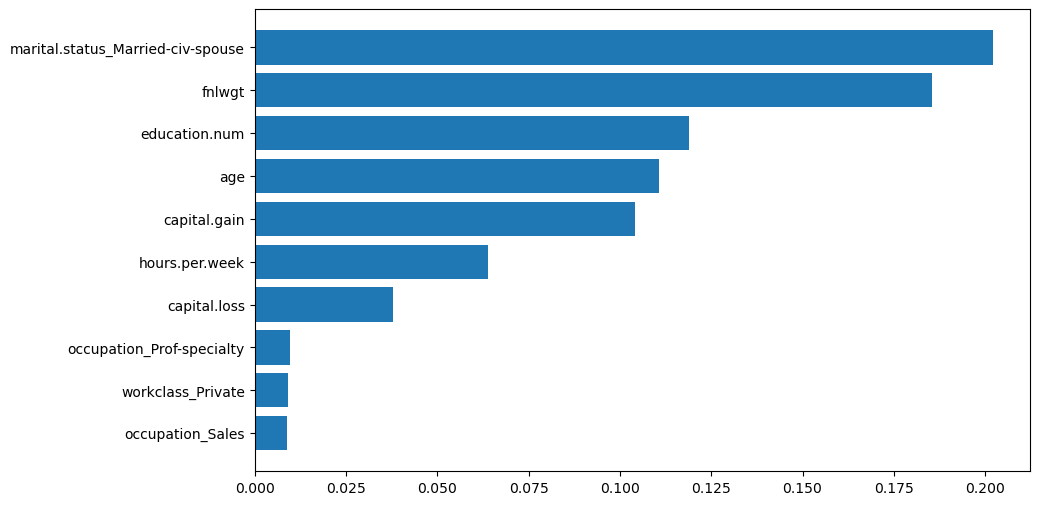

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias["Variable"][:10],
    importancias["Importancia"][:10]
)

plt.gca().invert_yaxis()

plt.show()

# Preguntas
## ¿Cuál es la variable objetivo?
La variable objetivo es income.
## ¿Qué representa dicha variable?
Representa si el ingreso anual de una persona es mayor a $50,000 (>50K) o menor o igual a $50,000 (<=50K).
## ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
La edad, el nivel educativo, el estado civil, la ocupación, las horas trabajadas por semana y las ganancias de capital (capital.gain), ya que están relacionadas con la experiencia laboral y el nivel socioeconómico.
## ¿Cuántas variables predictoras existen?
Existen 14 variables predictoras (todas las columnas excepto income).
## ¿Por qué fue necesario transformar variables categóricas?
Porque los algoritmos de Machine Learning trabajan con datos numéricos. El One-Hot Encoding convierte las variables categóricas en variables binarias para que el modelo pueda procesarlas correctamente.
## ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
Se generaron 82 columnas adicionales.
## ¿Existen valores nulos?
Inicialmente no había valores nulos (NaN), pero sí existían valores representados por "?" 
en las variables workclass, occupation y native.country, los cuales fueron identificados como datos faltantes.
## ¿Qué variables son numéricas?
age
fnlwgt
education.num
capital.gain
capital.loss
hours.per.week
## ¿Qué variables son categóricas?
workclass
education
marital.status
occupation
relationship
race
sex
native.country
income
## ¿Cuántos registros quedaron en entrenamiento?
Con un test_size = 0.20 y 32,561 registros, quedaron aproximadamente 26,048 registros para entrenamiento.
## ¿Cuántos registros quedaron en prueba?
Quedaron aproximadamente 6,513 registros para prueba.
## ¿Por qué no debemos entrenar utilizando todos los datos?
Porque es necesario reservar una parte de los datos para evaluar el desempeño del modelo con información que no haya visto durante el entrenamiento. Esto permite medir su capacidad de generalización y evitar el sobreajuste.
## ¿Cuál fue el Accuracy obtenido?
El Accuracy obtenido fue de 0.8018, es decir, aproximadamente 80.18 %.
## ¿Consideras que el resultado es adecuado?
Sí. Un Accuracy cercano al 80 % indica que el modelo realiza buenas predicciones y tiene un desempeño aceptable para este problema de clasificación, aunque todavía puede mejorarse ajustando hiperparámetros o utilizando modelos más avanzados.
## ¿Qué factores podrían afectar el desempeño del modelo?
La calidad de los datos.
La presencia de datos faltantes.
Variables irrelevantes o redundantes.
El desbalance entre clases.
El sobreajuste del árbol de decisión.
La configuración de los hiperparámetros del modelo.
## ¿Cuál fue la variable más importante?
La variable con mayor importancia fue marital.status_Married-civ-spouse, con una importancia aproximada de 0.2020.
## ¿Cuál fue la menos importante?
Varias variables obtuvieron una importancia de 0.0. Entre ellas se encuentran:
occupation_Armed-Forces
occupation_Priv-house-serv
native.country_Ecuador
native.country_Holand-Netherlands
native.country_Honduras
native.country_Peru
native.country_Outlying-US(Guam-USVI-etc)
native.country_Scotland
native.country_Taiwan
native.country_Thailand
## ¿Coinciden los resultados con tus hipótesis iniciales?
Sí. Era de esperarse que variables como el estado civil, la educación, la edad, las ganancias de capital y las horas trabajadas influyeran significativamente en el nivel de ingresos, y el modelo confirmó esa hipótesis.
## ¿Qué variables aportan más información al modelo?
De acuerdo con la importancia calculada por el árbol de decisión, las variables que más aportan son:
marital.status_Married-civ-spouse
fnlwgt
education.num
age
capital.gain
hours.per.week
capital.loss

Estas variables fueron las que tuvieron mayor peso en la clasificación del ingreso de las personas.

## Conclusion
En este laboratorio se implementó un modelo de árbol de decisión para predecir si los ingresos anuales de un individuo 
superan los $50,000 basándose en datos demográficos y laborales. 
El proceso incluyó un preprocesamiento integral mediante el tratamiento de valores faltantes y la aplicación de One-Hot Encoding. 
El modelo alcanzó una precisión del 80.18%, destacando factores como el estado civil, el nivel educativo y la edad como los principales predictores. Los resultados confirman la utilidad de los árboles de decisión para este tipo de clasificación, subrayando la importancia de la preparación de datos y sugiriendo que el rendimiento 
podría optimizarse mediante el ajuste de hiperparámetros o el uso de técnicas de aprendizaje más avanzadas.
